# Task 5 — Sales Prediction Using Python

Objective: predict sales from TV, Radio and Newspaper advertising spend.

In [1]:
import numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
df=pd.read_csv("Advertising.csv"); df.columns=df.columns.str.strip(); extra=[c for c in df.columns if c.lower() in {"x","unnamed: 0"}]; df=df.drop(columns=extra,errors="ignore"); print(df.shape); display(df.head()); print(df.dtypes); print(df.isnull().sum()); display(df.describe())

(200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


## 1. EDA

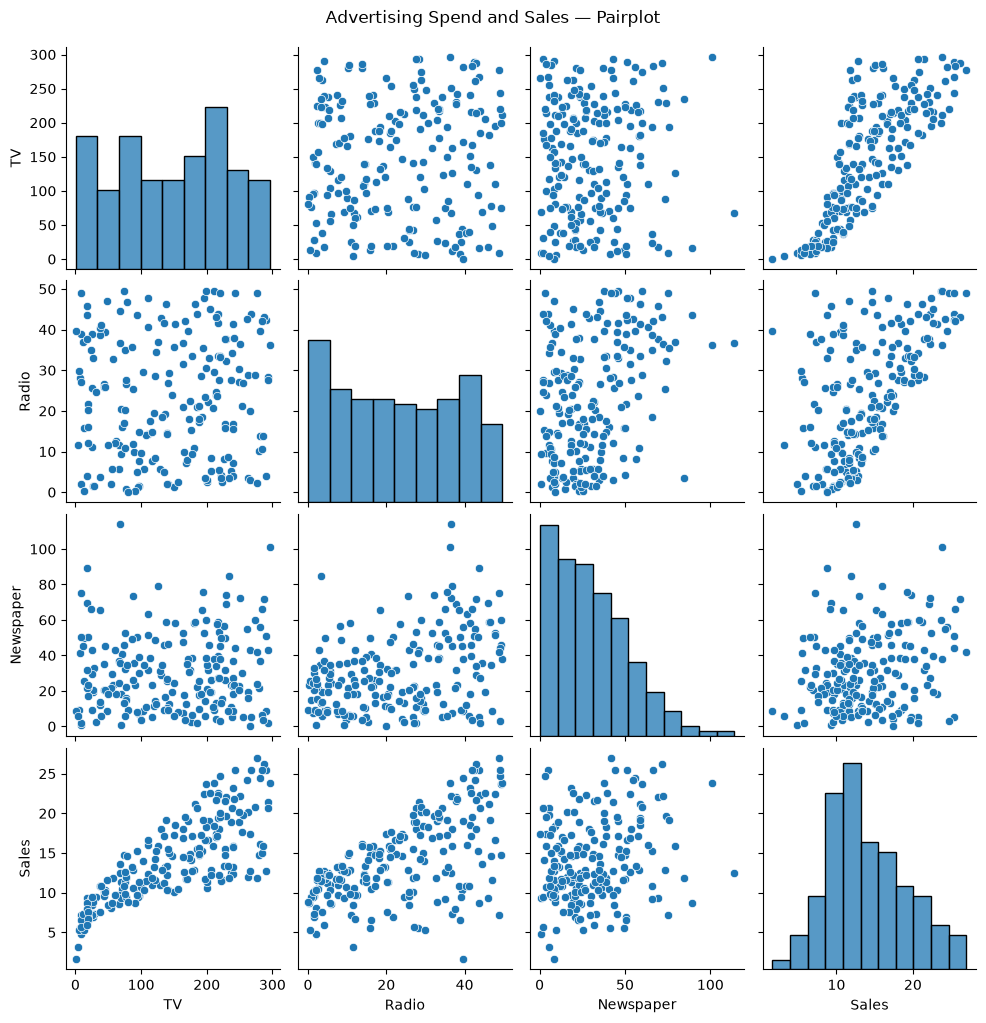

In [2]:
sns.pairplot(df); plt.suptitle("Advertising Spend and Sales — Pairplot",y=1.02); plt.show()

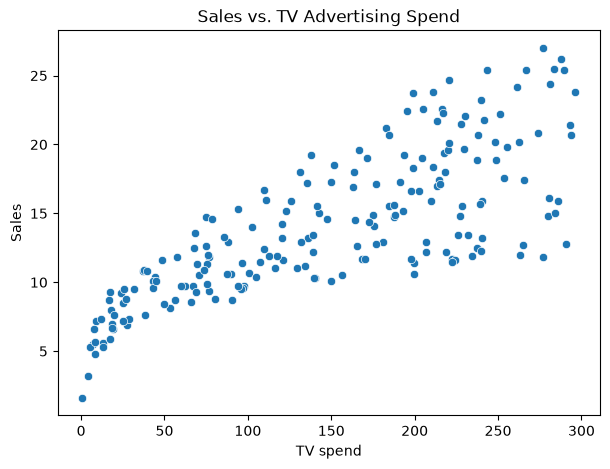

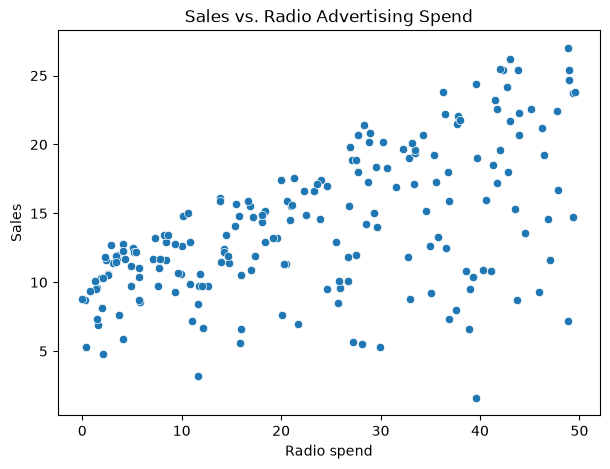

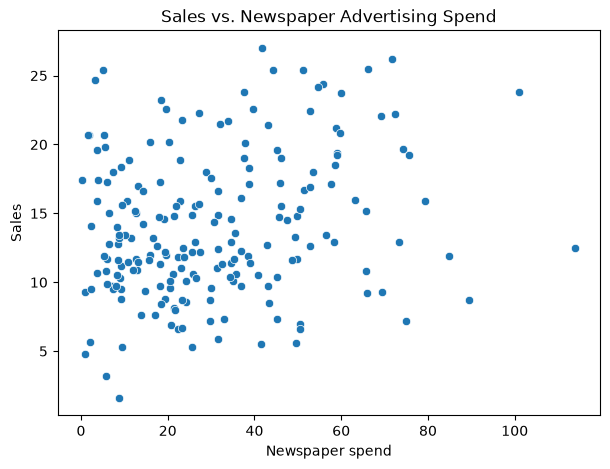

In [3]:
for channel in ["TV","Radio","Newspaper"]:
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=df,x=channel,y="Sales")
    plt.title(f"Sales vs. {channel} Advertising Spend")
    plt.xlabel(f"{channel} spend")
    plt.ylabel("Sales")
    plt.show()


**Observation:** The scatter plots reveal the strength and shape of each channel-to-sales relationship.

## 2. Correlation heatmap

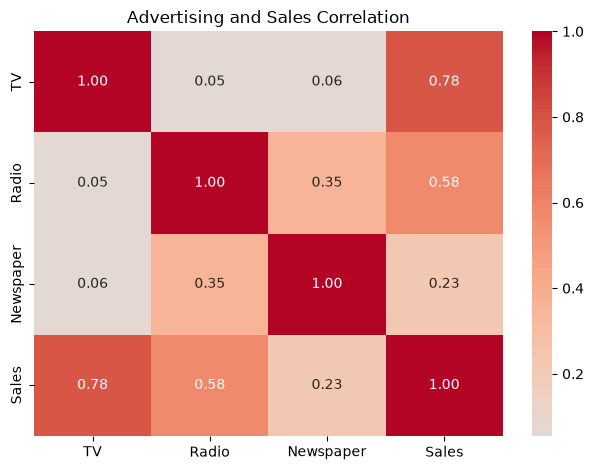

In [4]:
channels = ["TV", "Radio", "Newspaper"]

sns.heatmap(
    df[channels + ["Sales"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Advertising and Sales Correlation")
plt.tight_layout()
plt.show()

## 3. Train/test split

In [5]:
X=df[channels]; y=df.Sales; Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.20,random_state=42)

## 4. Linear baseline + additional models

In [6]:
models={"Linear Regression":LinearRegression(),"Random Forest":RandomForestRegressor(n_estimators=400,min_samples_leaf=2,random_state=42),"Polynomial Regression":Pipeline([("poly",PolynomialFeatures(degree=2,include_bias=False)),("model",LinearRegression())])}; results={}
for n,m in models.items():
 m.fit(Xtr,ytr); p=m.predict(Xte); results[n]={"model":m,"pred":p,"MAE":mean_absolute_error(yte,p),"RMSE":np.sqrt(mean_squared_error(yte,p)),"R²":r2_score(yte,p)}
metrics=pd.DataFrame({n:{"MAE":r["MAE"],"RMSE":r["RMSE"],"R²":r["R²"]} for n,r in results.items()}).T.sort_values("R²",ascending=False); display(metrics.round(4))

,MAE,RMSE,R²
Polynomial Regression,0.5262,0.6426,0.9869
Random Forest,0.6588,0.7919,0.9801
Linear Regression,1.4608,1.7816,0.8994


## 5. Residual plot for best model

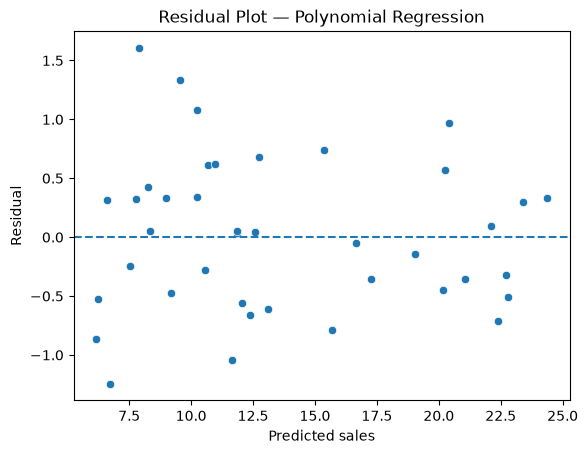

Best model: Polynomial Regression
MAE     0.526179
RMSE    0.642581
R²      0.986918
Name: Polynomial Regression, dtype: float64


In [7]:
best=metrics.index[0]; r=results[best]; residual=yte-r["pred"]; sns.scatterplot(x=r["pred"],y=residual); plt.axhline(0,ls="--"); plt.xlabel("Predicted sales"); plt.ylabel("Residual"); plt.title(f"Residual Plot — {best}"); plt.show(); print("Best model:",best); print(metrics.loc[best])

## 6. Highest-impact advertising channel

Raw coefficients:


,Coefficient
TV,0.044730
Radio,0.189195
Newspaper,0.002761


Standardized coefficients:


,Standardized Coefficient
TV,3.776015
Radio,2.801074
Newspaper,0.056151


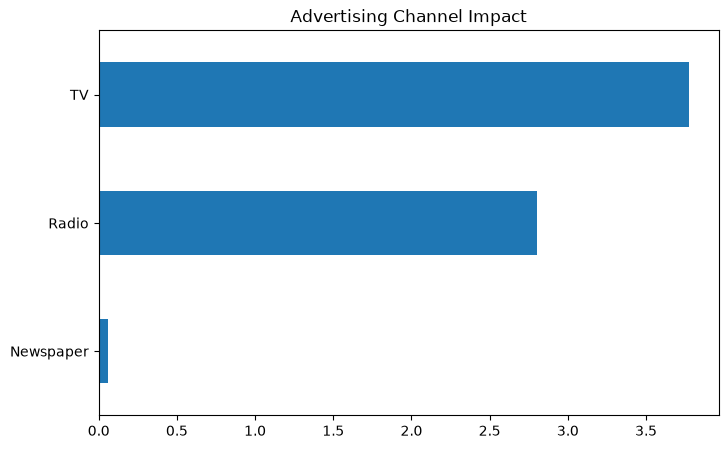

Highest-impact channel: TV


In [8]:
lin=results["Linear Regression"]["model"]; raw=pd.Series(lin.coef_,index=channels); Xstd=(Xtr-Xtr.mean())/Xtr.std(); std=LinearRegression().fit(Xstd,ytr); coef=pd.Series(std.coef_,index=channels).sort_values(key=np.abs,ascending=False); print("Raw coefficients:"); display(raw.to_frame("Coefficient")); print("Standardized coefficients:"); display(coef.to_frame("Standardized Coefficient")); coef.sort_values().plot(kind="barh",figsize=(8,5)); plt.title("Advertising Channel Impact"); plt.show(); print("Highest-impact channel:",coef.abs().idxmax())

## Final conclusion
The project includes data quality checks, pairplot, three individual scatter relationships, correlation heatmap, train/test split, Linear Regression baseline, additional regressors, MAE/RMSE/R², residual analysis and coefficient-based channel interpretation.